# Lab 047 · SAINT

## Build row attention. Measure what its companions change.

[Lesson 047](../lessons/0047-saint.html) · [Reproduction reference](../reference/saint-reproduction.html) · [Paper: Somepalli et al. (2021)](https://arxiv.org/abs/2106.01342v1)

**From Lesson 046:** you already turned each feature into a token and read a learned `[CLS]` summary. SAINT adds a second attention axis: whole rows can exchange information. Your goal is to implement that path and determine what belongs in its evaluation protocol.

**By EXIT you will have:** an invertible row-packing operator, independently checked attention, a stage whose forward pass you wrote, and a three-dataset experiment using that stage. You will also implement the paper's contrastive pairing term and explain why this alone does not reproduce pretraining.

| Route | What you do | Evidence you produce |
|---|---|---|
| 1 · Understand | Trace feature attention versus row attention | A prediction about changing a companion |
| 2 · Build | Complete Tasks 1–3, inspect real tensors | Values, gradients, and stage-wiring checks |
| 3 · Audit | Change companions; implement Task 4's loss | An intervention and a pairing check |
| 4 · Compare | Train 3 models × 3 datasets × 3 seeds | AUROC, uncertainty, ranks, context report |
| 5 · Reproduce | Attempt Bank with the visible scale-up runner | Saved artifacts and an honest scope verdict |

**How to work:** PROVIDED = read/run; TODO = write the focused blanks; CHECK = run immediately; EXIT = explain your actual evidence. Predict before executing each probe. Keep written answers in the marked markdown cells. The core lab is CPU-sized: the revised solution's comparison took 109 seconds on the authoring machine; reading and implementation take longer, and runtime varies by machine. Bank is a separate, deliberately gated compute step.

All mechanism diagrams are embedded in this file and visible before execution. The lesson offers their interactive versions. The student notebook intentionally has empty code outputs; the clearly labeled author-reference panels later in this notebook show an actual recorded run.

### The reproduction contract

| Evidence | Scope in this notebook | What it cannot establish |
|---|---|---|
| **Architecture** | Full supervised released-code path, implemented from scratch | That every PDF equation matches the release |
| **Mechanism probes** | Synthetic tensors isolate axes, pairing, and companion effects | Accuracy on a population |
| **Local training · Tier A** | Real `credit_g`, `diabetes`, `blood_transfusion`; 3 seeds; fixed split | Reproduction of the paper's Table 2 |
| **Pretraining** | One-way contrastive loss from §4, Eq. 5, as a key-parts exercise | Full augmentation/denoising training or Table 3 results |
| **Paper-results track** | Bank/Table 2 runner, three presets, persistent artifacts | A completed full-scale run merely because code exists |

The three local tables are substitutes. `credit_g` is **not** the paper's credit-card-fraud dataset. Paper tasks such as Bank, Blastchar, Arrhythmia, Arcene, Forest, Shoppers, Income, HTRU2, KDD99, Philippine, QSAR Bio, Shrutime, Spambase, Credit, Volkert, and MNIST are outside this local comparison; Bank has its own required next step.

The implementation target is the [official release pinned at `e288e84`](https://github.com/somepago/saint/tree/e288e84c77a54cfd2ffb55a53678fb7cbbb16630), audited against arXiv v1. The measured reference run is `_verify_l047_results.json`; `_sources_l047.json` records source provenance; `requirements-l047.lock.txt` snapshots the authoring environment. A downscaled experiment stays a different experiment even if it gives an attractive score.

### Recall first · the new axis

Without looking back at Lesson 046, write one sentence for each:
1. What information is initially present in `[CLS]`, and how does it acquire a row summary?
2. In feature self-attention, can changing another row change this row's output in evaluation mode?
3. Predict whether SAINT's answer will depend on the **order** of a fixed batch, its **membership**, both, or neither.

**Your prediction:** _write here before running the intervention._

### Model architecture — from a batch to predictions

The picture shows the **supervised colrow variant** implemented below. B = batch rows, T = feature count + one CLS token, d = token width, and L = repeated stages. Our local model uses L = 1 and d = 8; evaluation batches have at most 64 rows.

**Trace the path:** categorical lookups and numeric networks (1 → 100 → d, with ReLU between linear maps) make feature tokens; missing numbers have learned tokens. Add CLS. Each stage applies feature attention and a feed-forward network, packs whole rows, applies row attention and another feed-forward network, and restores tokens. Read the final CLS; a d → 1000 → 2 classifier with ReLU emits two logits. Softmax gives class probabilities; training cross-entropy consumes logits and labels.

Each attention/feed-forward sublayer uses the released-code residual: u = LayerNorm(x), then u + f(u). The Tasks below unpack this placement. Feature-only and row-only controls omit the other pair. Augmented views, projection heads and reconstruction heads belong to the paper's pretraining path, not this supervised prediction path.

**Trace before coding:** at which block can another row first influence the query row? Explain why the final CLS can carry that information.

<div style="overflow-x:auto;max-width:100%">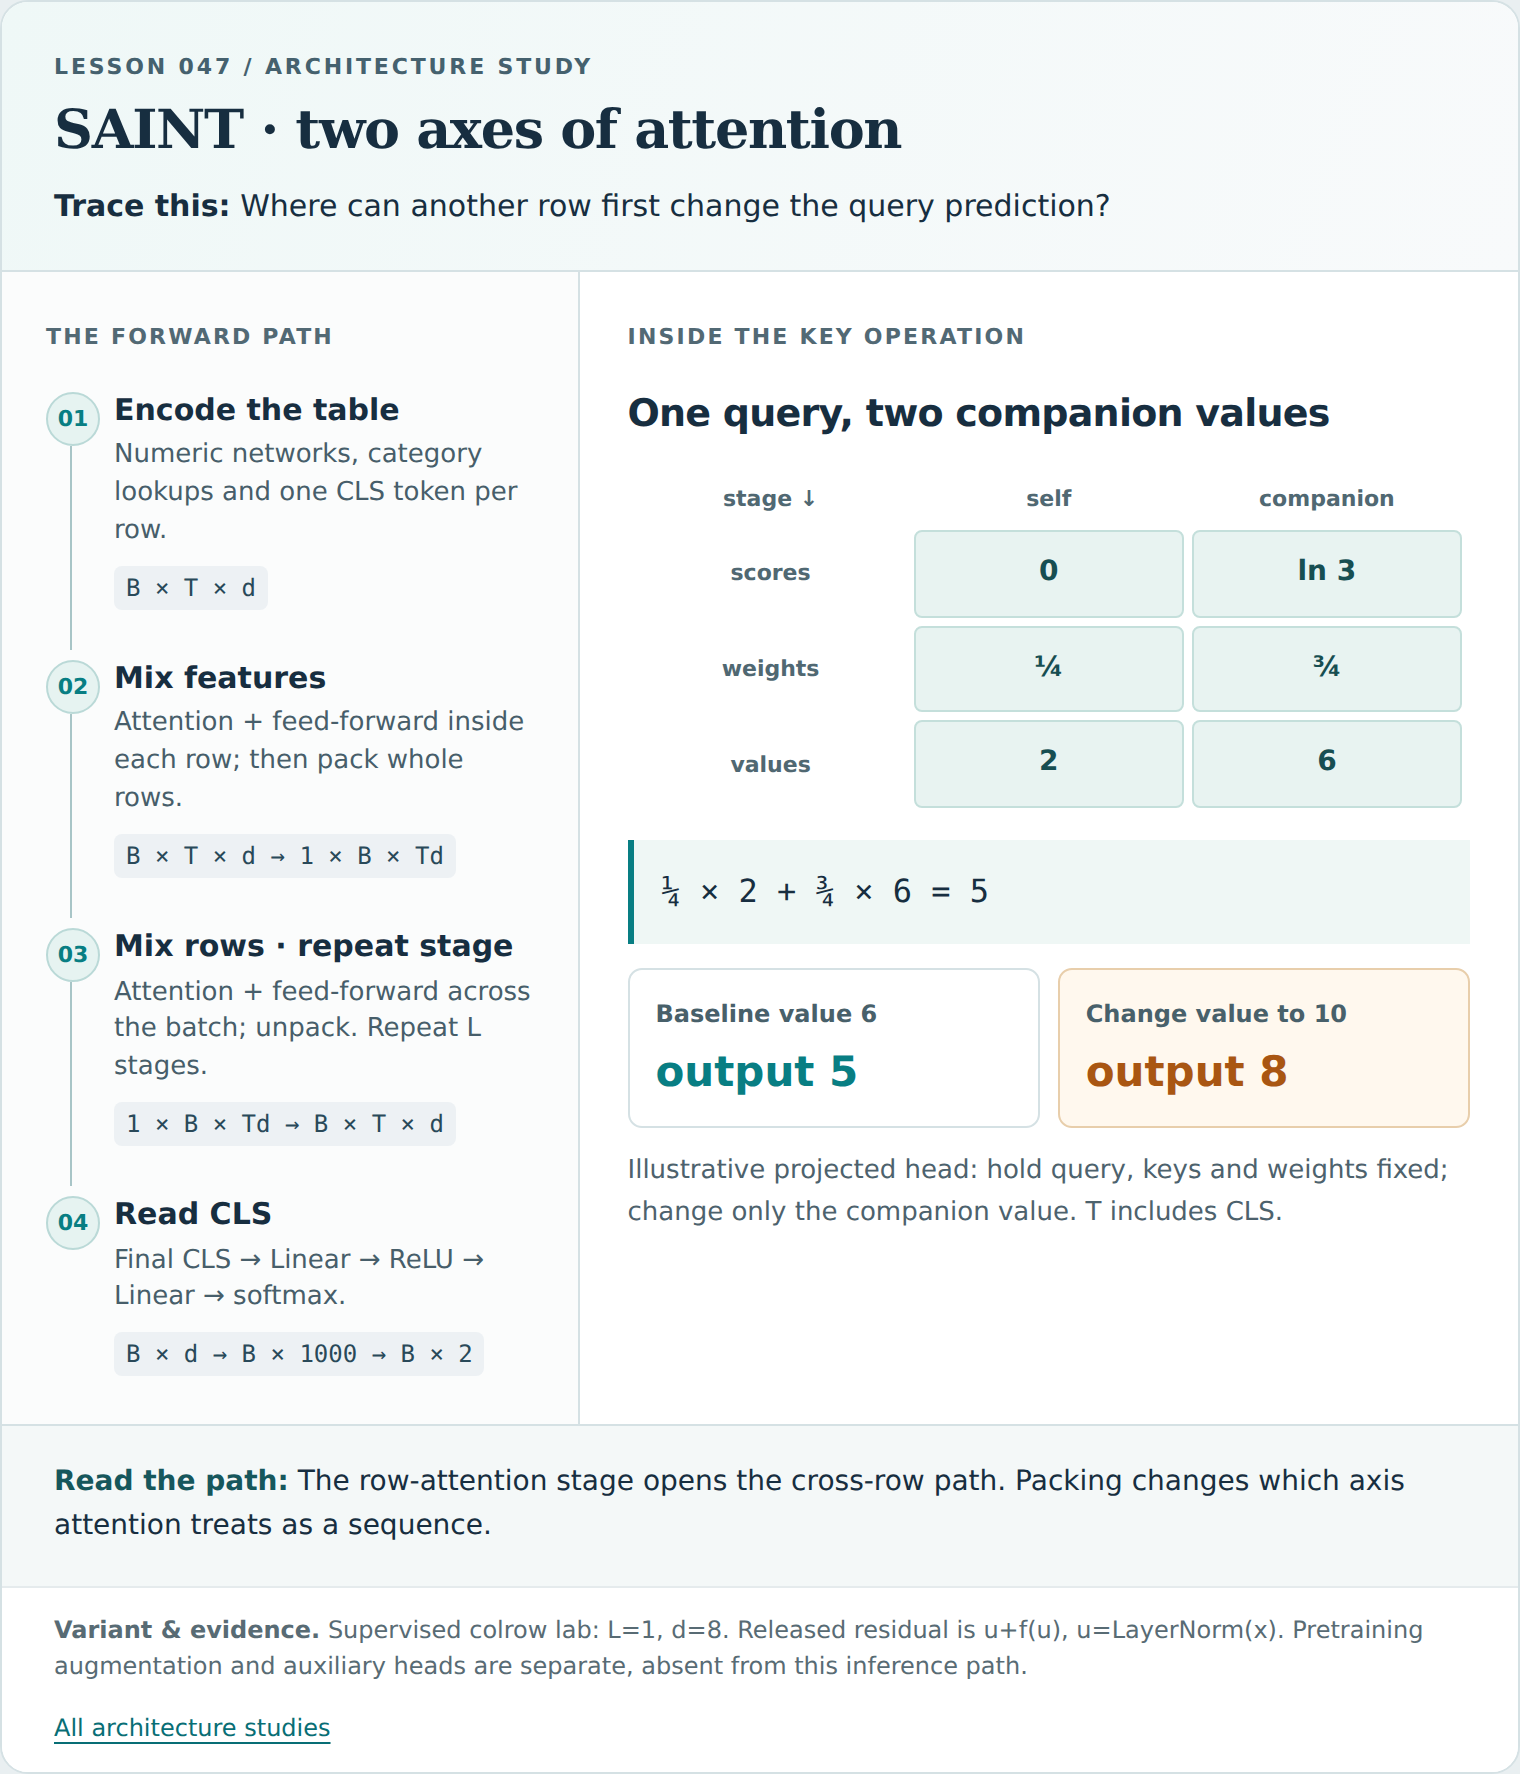</div>

*Portable architecture figure. On a narrow notebook screen, scroll horizontally to retain readable labels.* [Open the responsive diagram](https://avistian.github.io/relational/labs/html/architecture-review/0047-saint.html).

**Read the path:** The row-attention stage opens the cross-row path. Packing changes which axis attention treats as a sequence.

**Variant and evidence:** Supervised colrow lab: L=1, d=8. Released residual is u+f(u), u=LayerNorm(x). Pretraining augmentation and auxiliary heads are separate, absent from this inference path.

### Begin with what one number in the tensor represents

Imagine a customer table with age, annual spend, and subscription type. A cell such as “annual spend = 900” is one measurement, whereas a token is a learned vector representing that measurement. Its coordinates are not nine hundred different business facts. They are channels whose usefulness is learned through the prediction objective. Different columns need different encoders: the category “premium” in a subscription column should not automatically share a representation with the same word in an unrelated product column.

Write the token array as **H[b,t,j]**. The index b selects a row in the batch, t selects a feature token or the summary token, and j selects one embedding coordinate. If there are two customers, three feature tokens plus `[CLS]`, and embedding width two, the shape is `[2,4,2]`. There are sixteen scalar entries. The three axes describe different things; moving an axis changes which objects the attention mechanism treats as its sequence.

The `[CLS]` token starts as a learned vector repeated across rows. Initially it does not contain a particular customer's values. It becomes a row summary because attention lets it read that row's feature tokens. This explains why a classifier can use only the final `[CLS]` vector without ignoring the other features: their information has had a route into that vector. It also explains a useful debugging check. If the feature tokens cannot influence `[CLS]`, changing an input feature will not change the classifier through that route, however many layers the code declares.

The numeric encoders in the checked release are small feature-specific MLPs. A scalar goes through an affine map, a ReLU, and another affine map before entering attention. This can learn a piecewise nonlinear representation of age or spend. It does not create additional observations. A missing numeric value follows a learned missing-value representation instead of pretending that an observed zero and an unknown value mean the same thing. These are implementation details you can trace in `tokenize`, rather than properties you should infer from the word Transformer. The paper's architecture overview and the executable release are linked separately because their exact operation ordering differs. [SAINT architecture and release](https://github.com/somepago/saint/tree/e288e84c77a54cfd2ffb55a53678fb7cbbb16630).

### Follow a prediction backward

The final head maps a row's summary vector to two class logits. A logit is an unrestricted score; applying softmax makes the two scores into probabilities that sum to one. For logits `[0, log(3)]`, the positive-class probability is `3/(1+3)=0.75`. Cross-entropy penalizes the log probability of the correct class. It is therefore the head's error signal that teaches the summary token which feature and companion information is useful. Neither an attention weight nor an embedding coordinate is already a class probability.

## 1 · Concept recap: a batch becomes part of the input

A **token** is a learned vector for a feature; `[CLS]` is a learned summary slot, never the target label. Let $B$ be rows in the current batch, $T$ be tokens per row **including CLS**, and $d$ be coordinates per token.

Feature attention treats each row as a separate sequence: $[B,T,d]$. Each token can read other tokens from that same row. SAINT's **intersample attention** flattens every row into one vector of width $Td$ and treats all $B$ rows as one sequence: $[1,B,Td]$. The leading 1 means one sequence containing the whole batch; it does not mean there is only one data row.

The distinction is about **who can read whom**. Flattening preserves feature order. Transposing to attend down each column would leave each feature in a separate sequence and implement a different operator. After row attention, we restore $[B,T,d]$ so CLS and the feature tokens retain their slots.

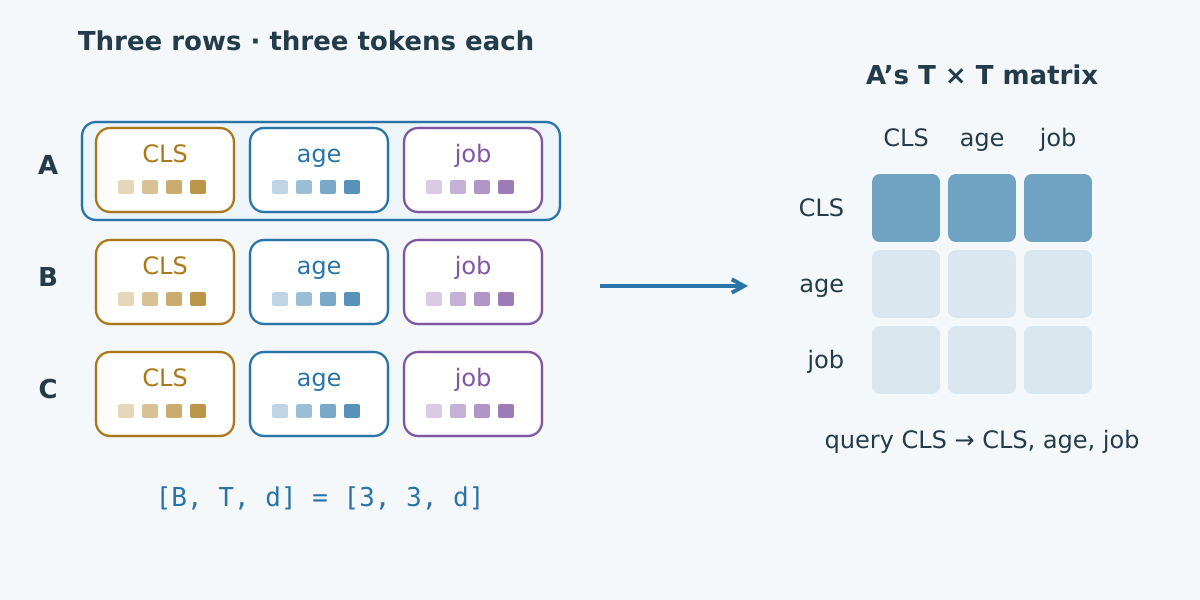

**Read the blue highlight:** one sequence per row. The drawing has B = 3 and T = 3 (CLS, age, job), so the input is `[3,3,d]` and the per-head attention matrix has shape `[3,H,3,3]`. The shaded matrix row marks the keys available to the CLS query; it does not show learned weights. See §3.2 / Algorithm 1.

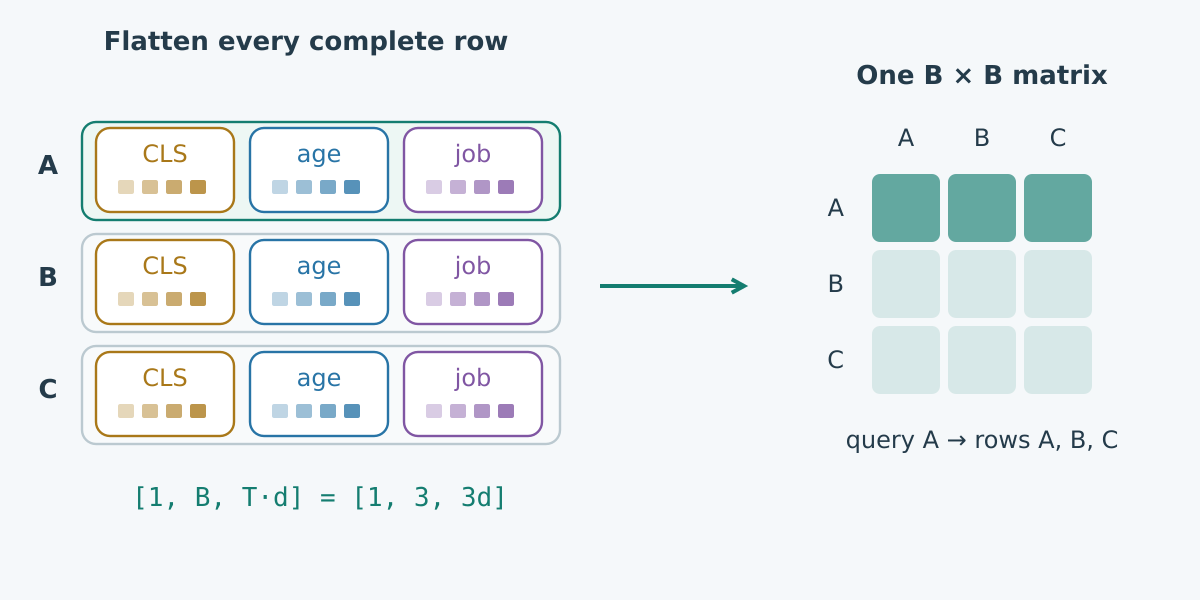

**Read the teal highlight:** each sequence element now contains every coordinate from one row. The same input becomes `[1,3,3*d]`, and the per-head attention matrix becomes `[1,H,3,3]`. Although both illustrated matrices happen to be 3×3, their axes mean different things: feature slots versus whole rows. No target labels are packed.

### A worked attention calculation

A query $q$ asks what to retrieve; keys $k_j$ determine match scores; values $v_j$ carry the information. For one head,

$$s_{ij} = q_i^	op k_j / sqrt{d_h},\qquad A_{ij}=\frac{e^{s_{ij}}}{\sum_\ell e^{s_{i\ell}}},\qquad o_i=\sum_j A_{ij}v_j.$$

Here $d_h$ is **head width**, not batch size. Each row of $A$ is a probability distribution over candidate keys. For scores `[1,0]` and scalar values `[2,8]`, weights are approximately `[0.731,0.269]` and the output is `0.731×2 + 0.269×8 = 3.614`. If only the first item remains, its weight becomes 1 and its output becomes 2. The query did not change; its available context did.

This will matter at deployment: $f(x_i;\mathcal B)$ can depend on the companion set $\mathcal B$. An evaluation batch size is consequently part of the prediction protocol.

### Queries, keys, and values have different jobs

A query is a vector describing what the receiving token is looking for. A key describes how a candidate source should be matched. A value is the information contributed if that source receives weight. Learned linear projections construct all three from the current representation. Calling them learned does not mean each has a human-readable role; their distinct roles come from the equations that consume them.

For one receiving token i, the score of source j is the dot product of its query and that source's key, divided by the square root of the key width. A dot product adds coordinate-wise agreements. The division keeps the typical magnitude of a sum of many roughly unit-scale terms from increasing merely because the embedding width increased. It is a scale convention, not a theorem that all trained attention scores have the same variance.

Softmax converts the score vector into nonnegative weights. Its denominator sums over **candidate sources for this receiver**. With scores `[0, log(3)]`, the weights are `[0.25,0.75]`. If their scalar values are `[2,6]`, the received value is `0.25×2 + 0.75×6 = 5`. Keep those scores fixed and change the second value from 6 to 10: the output becomes 8. The weights did not change, but the representation did. An attention heatmap alone therefore does not tell you the magnitude or sign of each source's contribution.

| Stage | Receiver reads | Score-array shape for one head | Example normalization |
|---|---|---|---|
| Feature attention | Feature tokens within its own row | `[B,T,T]` | Each length-T source row sums to one |
| Whole-row attention | Packed representations of companion rows | `[1,B,B]` | Each length-B source row sums to one |

The batch dimension B disappears into the sequence dimension in the second stage. That is the architectural change. It is not equivalent to running ordinary feature attention independently for every row, and it is not the same as attending across rows separately for each feature position.

### Why the reshape deserves its own exercise

Suppose one row's two tokens are `[1,2]` and `[3,4]`. Packing the whole row should produce `[1,2,3,4]`. A transpose followed by a reshape can produce `[1,3,2,4]`; its shape is still valid, but the coordinate convention has changed. If unpacking uses the original convention, information returns to the wrong feature positions. An invertibility check catches one class of bug, while a named-coordinate fixture catches the subtler case where pack and unpack agree with each other but disagree with the intended architecture.

After attention, multiple heads' outputs are concatenated and projected back to the required width. A head is a separate learned matching-and-aggregation channel, not a vote for one class. The output projection and subsequent nonlinear transformation can combine these channels. Read the notebook's `Attention.forward` from the final output backward: verify the restored width, then the concatenation order, then the value aggregation, then the axis used by softmax.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

In [ ]:
# PROVIDED — setup; local: open from repo root, labs/, or labs/solutions/
import os, sys, json, copy, hashlib
from pathlib import Path
os.environ.setdefault('OMP_NUM_THREADS', '1')
for candidate in (Path.cwd(), Path.cwd().parent, Path.cwd() / 'labs'):
    if (candidate / 'relkit').is_dir():
        LABS = candidate.resolve()
        sys.path.insert(0, str(LABS))
        break
else:
    raise RuntimeError('Open this notebook from the course repo or run the Colab bootstrap.')
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from relkit.saint_experiment import prepare, environment
from relkit.saint_report import score_table, paired_table, plot_scores, plot_ranks, plot_context
torch.set_num_threads(1)
torch.manual_seed(47)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
checks = {}
def check(name, condition, hint):
    checks[name] = bool(condition)
    assert checks[name], f'{name}: {hint}'
    print('PASS ·', name)
display(pd.Series(environment()['versions'], name='Installed version').to_frame())
print('Python:', environment()['python'], '| Device: CPU for the learning lab')

## 2 · Task 1 — pack and restore whole rows

**Goal:** make the two shape transformations in Algorithm 1 invertible while preserving every coordinate's owner.
**Why it matters:** a plausible shape can hide a feature/row permutation and train the wrong model.
**Hint boundary:** keep the row order and the within-row flattening order; use the supplied token count to recover the embedding width. Do not transpose columns into separate sequences.

Before running the check, predict where original coordinate `x[1,2,3]` will live in the packed tensor.

In [ ]:
# TODO — Task 1: two focused shape operations
def pack_rows(tokens):
    b, t, d = tokens.shape
    return ____

def unpack_rows(rows, n_tokens):
    return ____

In [ ]:
# CHECK — values, ownership, non-contiguous input, and gradients
x = torch.arange(60., requires_grad=True).reshape(3, 4, 5)
packed = pack_rows(x)
check('Packing shape', packed.shape == (1, 3, 20), 'The whole batch is one sequence of three rows.')
check('Coordinate ownership', torch.equal(packed[0, 1], x[1].flatten()), 'Keep all coordinates of row 1 together.')
check('Round trip', torch.equal(unpack_rows(packed, 4), x), 'Restore both feature and coordinate order.')
y = x.transpose(1, 2)
check('Non-contiguous input', torch.equal(unpack_rows(pack_rows(y), 5), y), 'The operator must preserve values even for a view.')
grad, = torch.autograd.grad(unpack_rows(packed, 4).square().sum(), x)
check('Packing preserves gradients', torch.equal(grad, 2*x), 'Reshaping must keep the autograd path.')
display(pd.DataFrame(packed.detach()[0].numpy(), index=['row 0', 'row 1', 'row 2']))

### Task 2 — normalize over candidate keys

**Goal:** implement the scaled scores and attention probabilities.
**Why it matters:** normalizing over queries can have a plausible shape but does not give each query a distribution over its companions.
**Hint boundary:** the final Q/K axis is head width. Scores need one axis for queries and one for keys. The test deliberately uses different query and key counts.

After your implementation passes, the provided multi-head module below will call **your function**.

In [ ]:
# TODO — Task 2: scores and probabilities
def attention_weights(q, k):
    scores = ____
    return ____

In [ ]:
# CHECK — independent PyTorch attention kernel, unequal query/key counts
generator = torch.Generator().manual_seed(47)
q = torch.randn(2, 3, 4, 7, generator=generator, dtype=torch.float64, requires_grad=True)
k = torch.randn(2, 3, 6, 7, generator=generator, dtype=torch.float64)
v = torch.randn(2, 3, 6, 5, generator=generator, dtype=torch.float64)
a = attention_weights(q, k)
check('Attention shape', a.shape == (2, 3, 4, 6), 'Four queries each read six keys.')
check('Key probabilities sum to one', torch.allclose(a.sum(-1), torch.ones_like(a.sum(-1))), 'Check the softmax axis.')
expected = F.scaled_dot_product_attention(q, k, v)
check('Independent kernel agreement', torch.allclose(a @ v, expected, atol=1e-12), 'Check the scale and key transpose.')
g1, = torch.autograd.grad((a @ v).square().sum(), q, retain_graph=True)
g2, = torch.autograd.grad(expected.square().sum(), q)
check('Attention gradient agreement', torch.allclose(g1, g2, atol=1e-11), 'A matching output must also train correctly.')

### PROVIDED · projected multi-head attention (§3.2)

`to_qkv` makes three projections and separates heads. Each head computes its own probability matrix; `a @ v` retrieves values; concatenation and `to_out` return to the input width. The **sequence length changes between feature and row attention**, while this module stays the same.

Read the shapes in order: `[batch, sequence, width] → [batch, heads, sequence, head_dim] → attention → [batch, sequence, width]`. In the release, feature heads have width 16 and row heads width 64. These head widths need not equal `d / heads`: the learned projections choose the internal width.

In [ ]:
# PROVIDED — §3.2: multi-head attention uses your Task 2
class Attention(nn.Module):
    def __init__(self, width, heads=4, head_dim=16):
        super().__init__()
        self.heads, self.head_dim = heads, head_dim
        self.to_qkv = nn.Linear(width, 3 * heads * head_dim, bias=False)
        self.to_out = nn.Linear(heads * head_dim, width)

    def forward(self, x):
        b, t, _ = x.shape
        q, k, v = [v.reshape(b, t, self.heads, self.head_dim).transpose(1, 2)
                   for v in self.to_qkv(x).chunk(3, dim=-1)]
        a = attention_weights(q, k)
        return self.to_out((a @ v).transpose(1, 2).reshape(b, t, -1))

## 3 · Assemble a released-code SAINT stage

The diagram opens one stage: feature attention and feed-forward transformation, then row attention and feed-forward transformation. A feed-forward network transforms each sequence element independently; attention is what allows information exchange. The model restores feature slots before reading CLS.

**Predict:** if the row block is removed, which part of the companion effect must disappear?

### Paper versus executable code · a choice that affects the function

A reproduction must state which source defines the operator. The pinned release and the PDF are not identical:

| Detail | PDF description | Pinned release / this notebook |
|---|---|---|
| Numeric embedding | Linear layer followed by ReLU | Per-feature `1 → 100 → d` MLP, with ReLU between layers |
| Residual/normalization | $x+\mathrm{LN}(F(x))$ | $u=\mathrm{LN}(x)$, then $u+F(u)$ |
| Feed-forward activation | Less explicit prose | GEGLU: split value and gate; multiply value by GELU(gate) |
| Attention dropout | Dropout is part of the configuration | Declared upstream but unused in attention forward; FF dropout is active |

**LayerNorm** normalizes the last dimension for each sequence element, then applies learned scale and bias. For feature attention this dimension is `d`; for row attention it is `T*d`. **GEGLU** expands width `w` to `8w`, splits it into two `4w` halves, gates them, and projects back to `w`.

The skip path below adds the **normalized** input. Replacing it with a familiar conventional residual block changes the model. `_check_l047.py` independently transplanted weights from the pinned official stage and recorded exact forward and input-gradient agreement; the notebook's later check compares your stage with that audited local implementation. Those are two distinct checks.

In [ ]:
# PROVIDED — Released gates and normalization; inspect the residual return value
class GEGLU(nn.Module):
    def forward(self, x):
        value, gate = x.chunk(2, dim=-1)
        return value * F.gelu(gate)


class ReleasedResidual(nn.Module):
    """Mirror the executable nesting, not a conventional PreNorm assumption."""
    def __init__(self, width, fn):
        super().__init__()
        self.norm, self.fn = nn.LayerNorm(width), fn

    def forward(self, x):
        u = self.norm(x)
        return u + self.fn(u)


def feedforward(width, dropout):
    return nn.Sequential(nn.Linear(width, 8 * width), GEGLU(),
                         nn.Dropout(dropout), nn.Linear(4 * width, width))

### Task 3 — wire the feature stage into the row stage

**Goal:** complete the forward pass of one whole SAINT stage.
**Why it matters:** implementing the attention equation is insufficient if it runs along the wrong axis, omits a sublayer, or fails to restore the token slots.
**Hint boundary:** run the feature sublayers first; preserve the token count before packing; each row sublayer consumes the packed representation. Restore the original representation afterward. The constructor is provided below; its `forward` is deliberately omitted.

`variant='col'` is the depth-matched feature-only control, `'row'` skips feature attention, and `'colrow'` runs both. The stage check exercises all three.

In [ ]:
# PROVIDED — Stage parameters only; you supply the actual forward pass next
class SaintStage(nn.Module):
    """Fig.1a: feature attention/FF, then entire-row attention/FF."""
    def __init__(self, tokens, d, heads=4, ff_dropout=0.1, variant='colrow'):
        super().__init__()
        if variant not in ('col', 'row', 'colrow'):
            raise ValueError(variant)
        self.variant = variant
        self.col = nn.ModuleList([
            ReleasedResidual(d, Attention(d, heads, 16)),
            ReleasedResidual(d, feedforward(d, ff_dropout)),
        ]) if variant != 'row' else nn.ModuleList()
        width = tokens * d
        self.row = nn.ModuleList([
            ReleasedResidual(width, Attention(width, heads, 64)),
            ReleasedResidual(width, feedforward(width, ff_dropout)),
        ]) if variant != 'col' else nn.ModuleList()

In [ ]:
# TODO — Task 3: three missing steps in the real stage
def saint_stage_forward(self, x):
    for layer in self.col:
        x = ____
    if self.row:
        t = x.shape[1]
        x = ____
        for layer in self.row:
            x = layer(x)
        x = ____
    return x

SaintStage.forward = saint_stage_forward

In [ ]:
# CHECK — copied weights isolate implementation, rather than training randomness
from relkit.saint import SaintStage as AuditedStage  # checker only; never the trained model
for variant in ('col', 'row', 'colrow'):
    torch.manual_seed(47)
    student = SaintStage(4, 8, ff_dropout=0., variant=variant).double().eval()
    reference = AuditedStage(4, 8, ff_dropout=0., variant=variant).double().eval()
    reference.load_state_dict(student.state_dict())
    x = torch.randn(5, 4, 8, dtype=torch.float64, requires_grad=True)
    got, expected = student(x), reference(x)
    check(f'{variant}: stage output', torch.allclose(got, expected, atol=1e-11), 'Check sublayer order and reshape boundaries.')
    g1, = torch.autograd.grad(got.square().sum(), x, retain_graph=True)
    g2, = torch.autograd.grad(expected.square().sum(), x)
    check(f'{variant}: stage gradient', torch.allclose(g1, g2, atol=1e-10), 'Keep the same differentiable operator.')
print('Official-source parity is recorded separately in _check_l047_results.json.')

### PROVIDED · tokens, missing values, and the prediction head

Each categorical feature owns an embedding table; each numeric feature owns an MLP. Numeric NaNs select a learned **feature-specific missing token**. Categorical code 0 is reserved for missing/unseen values by our training-only encoder. These choices preserve missingness while keeping a fixed token layout.

Read `tokenize` first: **CLS → categorical tokens → numeric tokens**. `encode` applies your stages. `forward` takes position 0 and maps `d → 1000 → 2` logits. Softmax is applied later when probabilities are needed; training cross-entropy consumes logits directly.

The constructor below resolves the `SaintStage` you just completed. The local comparison and the notebook's Bank runner will train this model.

In [ ]:
# PROVIDED — §3 / Fig. 1: full supervised model, using your Task 3 stage
class SAINT(nn.Module):
    """Released supervised path: CLS, cats, numeric MLPs, blocks, CLS→1000→2.
    Missing numeric inputs are NaN and get feature-specific learned mask tokens;
    categorical code 0 is the missing/unseen token reserved by our train-only encoder.
    """
    def __init__(self, n_num, cards, d=8, depth=1, heads=4,
                 ff_dropout=0.1, variant='colrow'):
        super().__init__()
        self.cls = nn.Parameter(torch.randn(1, 1, d))
        self.cats = nn.ModuleList([nn.Embedding(c, d) for c in cards])
        self.nums = nn.ModuleList([nn.Sequential(nn.Linear(1, 100), nn.ReLU(),
                                                nn.Linear(100, d)) for _ in range(n_num)])
        self.missing_num = nn.Parameter(torch.randn(n_num, d))
        t = 1 + n_num + len(cards)
        self.stages = nn.ModuleList([SaintStage(t, d, heads, ff_dropout, variant)
                                     for _ in range(depth)])
        self.head = nn.Sequential(nn.Linear(d, 1000), nn.ReLU(), nn.Linear(1000, 2))

    def tokenize(self, x_num, x_cat):
        b = len(x_num)
        parts = [self.cls.expand(b, -1, -1)]
        parts += [emb(x_cat[:, j]).unsqueeze(1) for j, emb in enumerate(self.cats)]
        for j, mlp in enumerate(self.nums):
            value = x_num[:, j:j+1]
            embedded = mlp(torch.nan_to_num(value))
            parts.append(torch.where(torch.isnan(value), self.missing_num[j], embedded).unsqueeze(1))
        return torch.cat(parts, dim=1)

    def encode(self, x_num, x_cat):
        x = self.tokenize(x_num, x_cat)
        for stage in self.stages:
            x = stage(x)
        return x

    def forward(self, x_num, x_cat):
        return self.head(self.encode(x_num, x_cat)[:, 0])

### Inspect real data before training

We use the real German-credit table here to inspect **representations**, not to make a predictive claim. The loader fixes split seed 5, forms a stratified 65/15/20 split, fits numeric means/scales and category vocabularies on training rows, and records the exact row IDs. Validation/test features use those fitted transforms; their labels do not enter tokenization.

The PDF's stated 65/15/25 percentages sum to 105%; the release uses 65/15/20. Our local **stratified** split differs from the release's random split assignment. The Bank runner later uses the released assignment, with remaining gaps still declared.

In [ ]:
# PROVIDED — inspect the actual fitted preprocessing and intermediate tensors
frame = prepare('credit_g')
meta = frame['meta']
display(pd.DataFrame({'Split': ['train', 'valid', 'test'],
                      'Rows': [len(frame[k]) for k in ('train', 'valid', 'test')]}))
display(pd.DataFrame({'Numeric feature': meta['numeric_columns'],
                      'Training mean': meta['train_numeric_mean'],
                      'Training scale': meta['train_numeric_std']}))
display(pd.DataFrame({'Categorical feature': meta['categorical_columns'],
                      'Training vocabulary size': [len(v) for v in meta['categorical_vocabularies']]}))
idx = frame['train'][:4]
xn = torch.tensor(frame['xn'][idx], dtype=torch.float32)
xc = torch.tensor(frame['xc'][idx], dtype=torch.long)
torch.manual_seed(47)
inspection_model = SAINT(xn.shape[1], frame['cards'], ff_dropout=0.).eval()
with torch.no_grad():
    tokens = inspection_model.tokenize(xn, xc)
    packed = pack_rows(tokens)
    encoded = inspection_model.encode(xn, xc)
    logits = inspection_model(xn, xc)
display(pd.DataFrame({'Tensor': ['numeric inputs', 'category codes', 'tokens', 'packed rows', 'encoded tokens', 'class logits'],
                      'Shape': list(map(lambda a: str(tuple(a.shape)), [xn, xc, tokens, packed, encoded, logits]))}))
check('Real token count', tokens.shape[1] == 1 + xn.shape[1] + xc.shape[1], 'Include CLS and every feature.')
check('Binary logits', logits.shape == (4, 2) and torch.isfinite(logits).all(), 'The head should produce two finite logits per row.')
print('Raw row IDs:', np.array(meta['row_ids'])[idx].tolist(), '| random untrained weights: no accuracy claim')

## 4 · Intervene on the context

**Goal:** separate permutation equivariance from independence of batch membership.
**Why it matters:** a model can treat row order symmetrically while still depending on which rows are present.

The figure uses a small synthetic weighted sum. Changing a companion's key changes its attention weight; the query remains fixed. In the code probe, we change one companion's full token representation and inspect the unchanged query row. We then permute the same batch and align the outputs again. Dropout is disabled and both stages are in evaluation mode, so stochastic dropout cannot explain a difference.

### Separate reordering, replacement, and new information

Take a fixed customer q and a batch containing q, customer a, and customer b. A permutation changes their order while preserving their values and membership. If the relevant operations are permutation-equivariant, the output for q follows q to its new position and retains its value. “Equivariant” means the output arrangement changes consistently with the input arrangement. It does not mean that all input arrangements or populations produce the same representation.

Replacement is a different intervention: swap b for customer c. Now the candidate keys and values available to q change. Even with dropout disabled, q can receive a different representation and prediction. Evaluation mode switches off training-only randomness; it does not remove the whole-row attention operation. If a model is meant to predict one customer at a time, the deployment procedure must still specify which companion rows, if any, are available.

There are at least three legitimate but different protocols: predict a row in isolation; predict it with a fixed reference batch; or predict all currently arriving unlabeled rows together. The last procedure uses other query features and is transductive with respect to that query batch. It is not automatically target leakage, because no query labels need enter the model, but it answers a different operational question from independent single-row prediction. These distinctions become essential when comparing SAINT with a model whose output is independent of test-batch membership.

For a controlled sensitivity experiment, hold model parameters, the query's values, preprocessing, and stochastic settings fixed. Vary only the companion set. Report a probability difference for the same query, rather than comparing two aggregate scores on different query populations. A large difference establishes dependence on context under that intervention. It does not establish improved accuracy, and a small difference for one query does not establish independence for every query.

### What would count as an informative failure?

If shuffled batches change the query's prediction after outputs are aligned by row identity, inspect positional assumptions, the pack/unpack convention, batch-dependent preprocessing, and randomness. If replacement changes predictions but permutation does not, that is consistent with set-sensitive computation. If both changes have no effect, check whether the row branch is inactive, whether its projection is near zero, or whether this query happens to be insensitive. Distinct hypotheses need distinct interventions; calling every discrepancy “attention instability” explains none of them.

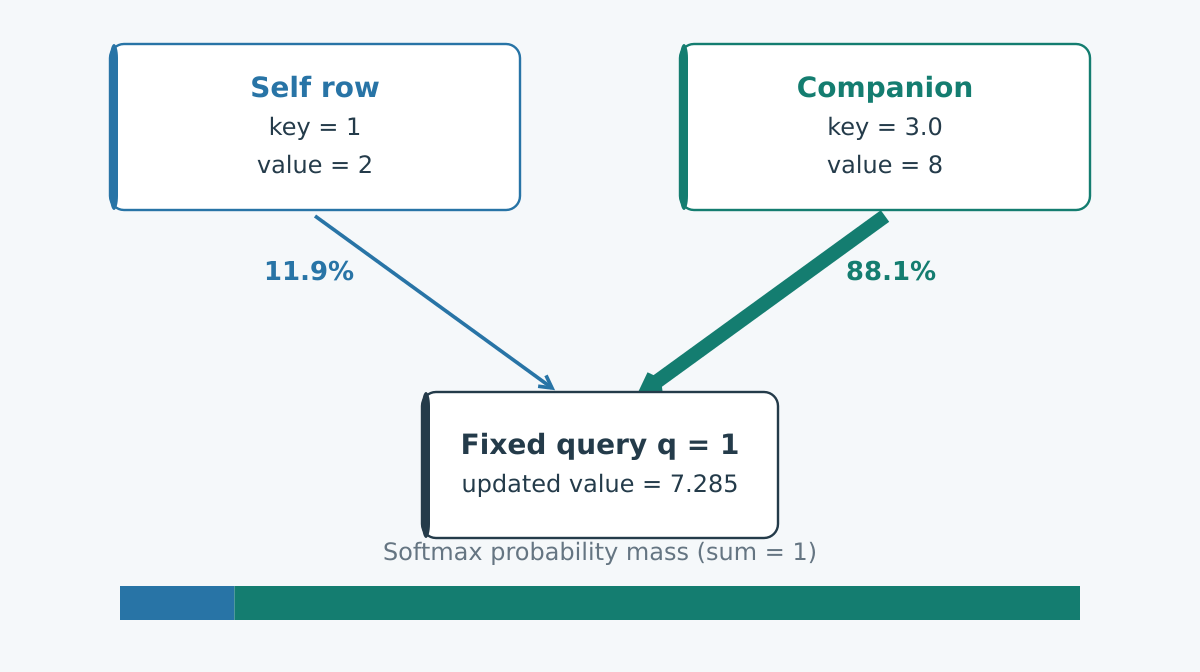

**Synthetic mechanism illustration.** The weights sum to one over available keys. This explains a possible dependency; it is not a trained probability or an accuracy result.

In [ ]:
# PROVIDED + CHECK — hold the query fixed, manipulate only companions
torch.manual_seed(47)
x = torch.randn(5, 4, 8)
row = SaintStage(4, 8, ff_dropout=0.).eval()
col = SaintStage(4, 8, ff_dropout=0., variant='col').eval()
changed = x.clone()
changed[1] = torch.randn_like(x[1]) * 3  # row 0, our query, is untouched
with torch.no_grad():
    row_delta = (row(x)[0] - row(changed)[0]).abs().max().item()
    col_delta = (col(x)[0] - col(changed)[0]).abs().max().item()
    perm = torch.tensor([3, 1, 4, 0, 2])
    permutation_error = (row(x)[perm] - row(x[perm])).abs().max().item()
check('Companion changes row-attention output', row_delta > 1e-6, 'Trace whether row 0 can read row 1.')
check('Feature-only control is independent', col_delta < 1e-6, 'Feature attention must not mix different rows.')
check('Permutation equivariance', permutation_error < 1e-5, 'Reordering the same rows should reorder outputs.')
display(pd.DataFrame({'Intervention': ['Change companion / feature only', 'Change companion / feature + row', 'Permute same batch / align outputs'],
                      'Max absolute change': [col_delta, row_delta, permutation_error]}))

**Explain the intervention before continuing:** _Was your opening prediction right? Why does the permutation check not imply independence of batch membership? If a deployed query is evaluated alone, what needs to be recorded alongside the weights?_

### Task 4 · What does the contrastive objective actually pair?

The paper also proposes self-supervised pretraining (§4). It makes a corrupted view through **CutMix on raw feature values** (replace selected features with another row's) and **mixup in embedding space** (a convex combination of representations). The clean and augmented paths go through the encoder and projection heads to produce vectors `z` and `z_view`. Contrastive matching and feature reconstruction provide two distinct learning signals.

This notebook trains only the supervised path. The next task isolates the contrastive loss; it does **not** implement the full augmentation sampler, projection/denoising training, or the Table 3 experiment. Read the diagram to understand where the loss inputs would come from.

### A positive pair is an identity claim

The contrastive exercise starts with two views of each original row. A view is an altered representation of that same example, constructed by an augmentation procedure. It is not another randomly selected row with the same class. If row i in the first view and row i in the second view are declared a positive pair, the loss assumes that their shared identity should survive the augmentation.

For one anchor, compute a similarity score with every candidate in the other view. Softmax turns those scores into probabilities over candidate identities, and cross-entropy rewards the matching identity. With two candidates and scores `[2,0]`, the positive candidate in position zero receives probability `exp(2)/(exp(2)+1)≈0.881`, giving loss about 0.127. If the second view is accidentally permuted but the positive indices remain unchanged, the same confident scores can be rewarded for matching the wrong examples. Tensor shapes and decreasing training loss will not reveal that semantic error.

The temperature divides similarities before softmax. A lower temperature sharpens their relative influence. In the example, dividing `[2,0]` by two produces `[1,0]`, positive probability about 0.731, and loss about 0.313. This does not mean colder temperatures always produce better representations: gradients, augmentation difficulty, false negatives, and feature scale also change the training problem. Vector normalization is another explicit choice. Dot products depend on both length and direction; cosine similarity removes the length contribution. The notebook implements the stated one-way dot-product objective and does not silently add a different normalized, symmetric variant.

Augmentations also encode assumptions. Replacing part of a row can teach robustness to missing or corrupted fields, but it can create impossible combinations if fields obey constraints. A representation objective cannot decide by itself whether replacing a birth date while preserving age is a meaningful example. Inspect what invariances the augmentation encourages before interpreting a good contrastive score as useful supervised knowledge. [SAINT pretraining objective, Section 4](https://arxiv.org/html/2106.01342v1#S4).

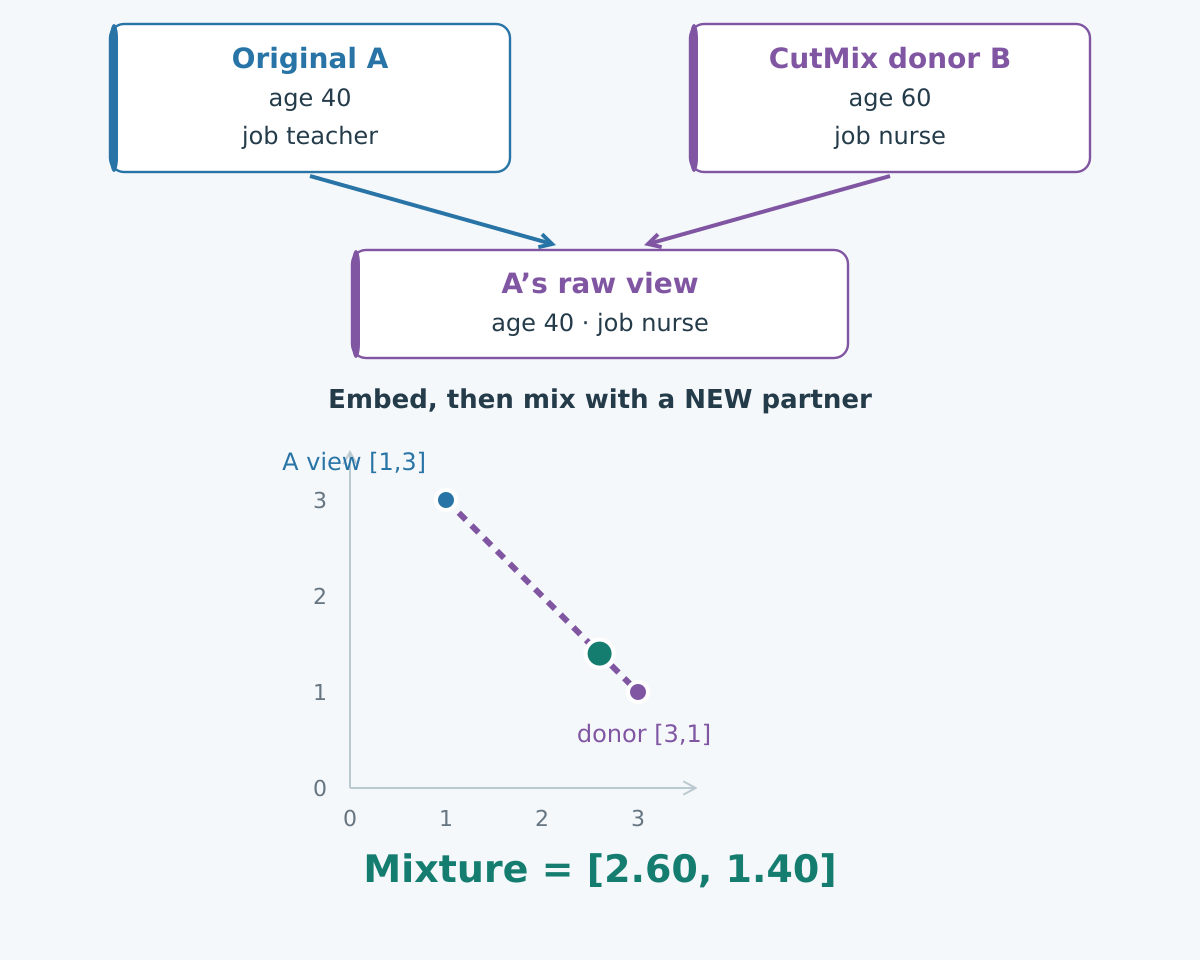

**Synthetic view construction, §4 / Fig. 1.** Follow the donor feature, then the weighted embedding coordinates. These values illustrate the transformations and are not learned representations from our benchmark.

**Goal:** compute Eq. 5's one-way contrastive pairing term using no class labels.
**Why it matters:** the positive is the **same row's augmented view**, not an arbitrary example with the same target class.
**Hint boundary:** create the pairwise similarity matrix, scale by positive temperature $\tau$, and identify the corresponding view by its row index.

$$\ell_i=-\log\frac{\exp(z_i^\top z'_i/\tau)}{\sum_j \exp(z_i^\top z'_j/\tau)}.$$

We use the **mean** over rows, a batch-size-independent rescaling of the paper's sum. No vector normalization is implicit in this exercise; the released pretraining code also offers a symmetric, normalized variant. Decreasing temperature sharpens a fixed similarity distribution; it does not magically correct a wrong positive pairing.

**Worked baseline:** with four identical candidate scores, each candidate gets probability 1/4 and loss is $-\log(1/4)=\log 4\approx1.386$. Denoising is a separate objective: reconstruct original features from the corrupted view. Class labels enter neither of these self-supervised targets.

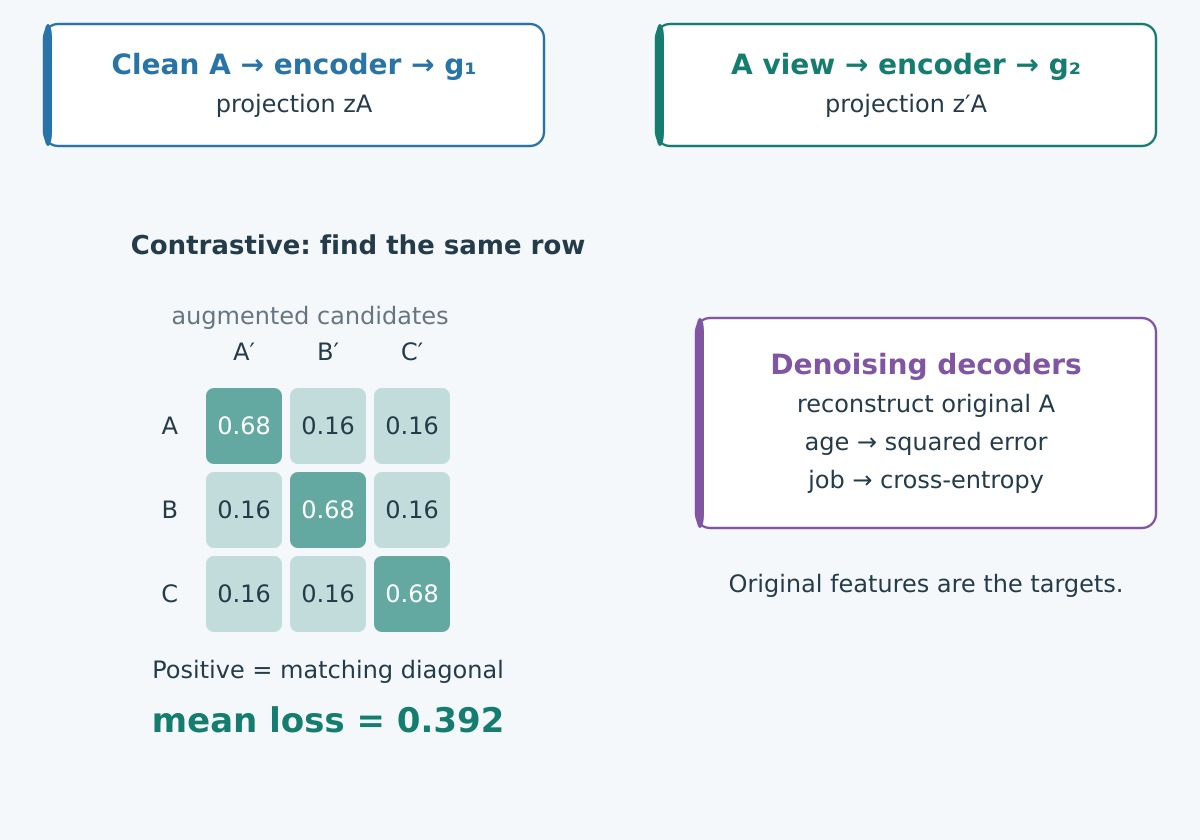

**Read the diagonal:** one correct augmented view per clean row. Off-diagonal candidates compete in the softmax. The reconstruction branch is conceptually separate and is not trained in this lab.

In [ ]:
# TODO — Task 4: paired-view contrastive loss
def info_nce(z, z_view, temperature=.7):
    logits = ____
    return ____

In [ ]:
# CHECK — pairing, uniform baseline, and differentiability
z = torch.eye(4, requires_grad=True)
check('Correct pairing beats a shuffled view', info_nce(z, z) < info_nce(z, z.roll(1, 0)), 'The positive view keeps the same row index.')
uniform_loss = float(info_nce(torch.zeros(4, 3), torch.zeros(4, 3)))
check('Uniform loss = log(B)', abs(uniform_loss - np.log(4)) < 1e-6, 'Use a mean cross-entropy over candidates.')
loss = info_nce(z, z)
grad, = torch.autograd.grad(loss, z)
check('Contrastive gradient is finite and nonzero', torch.isfinite(grad).all() and grad.abs().max() > 0, 'Keep the loss as a differentiable tensor.')
print(f'Uniform baseline: {uniform_loss:.4f}; matching identity vectors: {loss.item():.4f}')

In [ ]:
# PROVIDED — see how temperature sharpens the SAME pairing
z = torch.eye(4)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.8), layout='constrained')
for ax, temperature in zip(axes, (.2, .7, 2.)):
    probabilities = (z @ z.T / temperature).softmax(-1).numpy()
    ax.imshow(probabilities, vmin=0, vmax=1, cmap='Blues')
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{probabilities[i,j]:.2f}', ha='center', va='center',
                    color='white' if probabilities[i,j] > .55 else '#183049')
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xlabel('Candidate view j'); ax.set_ylabel('Clean row i')
    ax.set_title(f'τ = {temperature} · loss {info_nce(z,z,temperature).item():.3f}')
fig.suptitle('Synthetic identity vectors · same-row positives lie on the diagonal', fontsize=13)
plt.show()

**Interpret, then transfer:** _Why is a class label the wrong target for this matrix? Which blocks and experiment are still missing before you could claim to reproduce SAINT pretraining?_

## 5 · Train the model you built

**Read the evaluator before the trainer.** `predict_saint` makes ascending-index batches within the supplied split, converts logits to positive-class probabilities, and never takes labels. Changing its `batch_size` changes companion membership. We keep validation and test rows in separate prediction calls.

The training loop then shuffles **training rows only**, minimizes supervised cross-entropy, and selects the best checkpoint using validation AUROC. It uses the whole fixed epoch budget rather than early stopping. The model seed must be set **before construction** as well as inside the training loop: reseeding after initialization cannot recover identical starting weights.

In [ ]:
# PROVIDED — Within-split evaluation; the companion policy is explicit
@torch.no_grad()
def predict_saint(model, xn, xc, batch_size=64, device='cpu'):
    """Within-split sequential batches. Their order/membership are model inputs.
    Never mix validation and test rows, and never pass labels into forward.
    """
    model.eval()
    out = []
    for start in range(0, len(xn), batch_size):
        num = torch.as_tensor(xn[start:start+batch_size], dtype=torch.float32, device=device)
        cat = torch.as_tensor(xc[start:start+batch_size], dtype=torch.long, device=device)
        out.append(model(num, cat).softmax(-1)[:, 1].cpu().numpy())
    return np.concatenate(out)

### PROVIDED · supervised optimization and checkpoint selection

Follow one epoch: permute training indices → form a batch → forward → cross-entropy → backward → optimizer step → evaluate validation split → retain best weights. `best` is a deep copy so later updates cannot silently alter the saved model. Test AUROC is measured only after checkpoint selection.

There is no contrastive pretraining call in this loop. Task 4's function is used by its own loss checks/visualization; Tasks 1–3 are used by the supervised model.

In [ ]:
# PROVIDED — Visible supervised training loop; no model implementation is imported
def train_saint(model, xn, xc, y, train, valid, *, seed=0, epochs=20,
                batch_size=64, lr=1e-3, device='cpu', checkpoint=None,
                select_metric='auc', validate_every=1):
    """Supervised AdamW, validation-only selection, checkpoint best weights.
    Call torch.manual_seed BEFORE constructing the model as well as here.
    No early stopping: a fixed budget makes the local ablation interpretable.
    """
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    num = torch.as_tensor(xn, dtype=torch.float32, device=device)
    cat = torch.as_tensor(xc, dtype=torch.long, device=device)
    labels = torch.as_tensor(y, dtype=torch.long, device=device)
    best, best_score, history = None, -float('inf'), []
    for epoch in range(epochs):
        model.train()
        order = rng.permutation(train)
        for start in range(0, len(order), batch_size):
            idx = order[start:start+batch_size]
            optimizer.zero_grad()
            loss = F.cross_entropy(model(num[idx], cat[idx]), labels[idx])
            loss.backward()
            optimizer.step()
        if epoch % validate_every == 0:
            p = predict_saint(model, xn[valid], xc[valid], batch_size, device)
            score = (float(np.mean((p >= .5) == y[valid])) if select_metric == 'accuracy'
                     else float(roc_auc_score(y[valid], p)))
            history.append({'epoch': epoch + 1, 'valid_score': score})
            if score > best_score:
                best_score, best = score, copy.deepcopy(model.state_dict())
                if checkpoint:
                    torch.save({'weights': best, 'epoch': epoch + 1, 'seed': seed,
                                'valid_score': score}, checkpoint)
    model.load_state_dict(best)
    return model, history

### The comparison frame · freeze it before looking at test scores

| Choice | Local protocol |
|---|---|
| Data and split | 3 real Tier-A tables; split seed 5; stratified 65/15/20; identical splits across arms |
| Preprocessing | Train-only numeric means/scales and categorical vocabulary; shared prepared inputs |
| Neural models | Feature only vs feature + row; d=8, depth=1, 4 heads, FF dropout .1 |
| Training | Model seeds 0/1/2, 20 epochs, AdamW lr=.001, weight decay=.01, batch 64 |
| Selection | Validation AUROC after each epoch, restore best weights |
| CatBoost | 300 iterations, depth 6, lr=.05, same seeds/splits, best validation-AUC model |
| Test context | Ascending row index within the test split, fixed batches of 64, no labels in forward |
| Context audit | Hold trained weights fixed; compare batch 64 with singleton evaluation |

**What is controlled:** feature-only and combined neural models share depth and the training budget. **What also changes:** adding the row block adds parameters and compute. Inspect their counts below; this is not a parameter-matched causal estimate of attention alone. The feature-only arm is not the paper's six-stage SAINT-s. CatBoost is a budgeted, untuned external baseline, not the best possible tuned tree.

**Uncertainty:** sample SD describes variation over three model seeds on one fixed split. The reported 95% seed intervals are conditional on that split and fragile at n=3; they are not population confidence intervals. Cross-dataset ranks use one seed-mean score per model per dataset, not nine independent datasets.

In [ ]:
# PROVIDED — make the added capacity visible on the inspected real table
counts = []
for variant in ('col', 'colrow'):
    torch.manual_seed(0)
    candidate = SAINT(frame['xn'].shape[1], frame['cards'], variant=variant)
    counts.append({'Model': variant, 'Trainable parameters': sum(p.numel() for p in candidate.parameters() if p.requires_grad)})
display(pd.DataFrame(counts))

**Pre-register your expectation:** _Which dataset, if any, do you expect row attention to help? What result would make you keep the feature-only model? Name a context-policy detail you must hold fixed._

In [ ]:
# PROVIDED — the harness injects YOUR visible model, trainer, and predictor
from _verify_l047 import run
result = run(model_cls=SAINT, train_fn=train_saint, predict_fn=predict_saint)
# Save both metrics/protocol and the executed cell source that produced them.
executed_source = '\n\n# --- next executed cell ---\n\n'.join(get_ipython().history_manager.input_hist_raw[1:])
source_hash = hashlib.sha256(executed_source.encode()).hexdigest()
artifact_dir = Path('l047_student_artifacts')
artifact_dir.mkdir(exist_ok=True)
(artifact_dir / 'executed_cells.py').write_text(executed_source)
result['notebook_source_sha256'] = source_hash
(artifact_dir / 'results.json').write_text(json.dumps(result, indent=2))
print(f'Saved to {artifact_dir.resolve()} · training elapsed {result["wall_s"]:.1f}s')

In [ ]:
# CHECK — completeness, protocol boundaries, and the independent-row control
check('Three datasets', len(result['results']['per_dataset']) == 3, 'Run the full local comparison.')
for dataset, arms in result['results']['per_dataset'].items():
    check(f'{dataset}: three seeds per model', all(len(a['scores']) == 3 for a in arms.values()), 'Do not turn seed runs into separate datasets.')
for dataset, protocol in result['protocols'].items():
    tr, va, te = [set(protocol[k]) for k in ('train', 'valid', 'test')]
    check(f'{dataset}: all split boundaries', not (tr & va or tr & te or va & te), 'Training, validation, and test must be disjoint.')
controls = [p['max_abs_probability_change'] for name, p in result['context_probe'].items() if name.endswith('/col')]
check('Trained feature-only context control', max(controls) < 1e-5, 'Independent-row predictions should be unchanged within floating-point tolerance.')
display(score_table(result).round(4))

### Read your result · first within each dataset

The chart shows each measured seed, its mean, and ±1 **sample SD**. The common AUROC axis makes differences visible without pooling datasets. AUROC measures positive/negative ranking quality; it does not establish calibrated probabilities or deployment utility.

The paired table subtracts feature-only AUROC from feature+row AUROC at the same seed. Positive means the combined model did better in that pair. Pairing aligns the experiment's seed labels; the architectures have different parameter sets, so it does not make their initial weights identical. Look for disagreement across seeds before summarizing a mean gap.

### Read the supervised comparison as a chain of decisions

An architecture specifies possible computations. A training procedure selects parameters using a dataset, initialization, optimizer, and stopping rule. An evaluation procedure specifies preprocessing, query batches, and scoring. The reported AUROC belongs to that whole chain. A source-parity check can establish a matching forward operation while leaving the training and evaluation chains different from the paper.

AUROC asks how often a positive example receives a higher score than a negative example, with a tie convention. It does not evaluate whether a prediction of 0.8 corresponds to an 80% event rate. Log loss and calibration diagnostics ask different questions. A model can rank rows well while being badly calibrated, so preserve the intended prediction use when deciding which metric belongs in the report.

Three model seeds on a fixed train/test split expose some variation in optimization and initialization. They do not turn one dataset into three independent datasets, and they do not measure variation across alternate populations or future time windows. Compare models within each dataset first. A paired seed difference holds the evaluated rows fixed, reducing one source of accidental variation. Then average seed results inside a dataset before giving that dataset a vote in the cross-dataset ranking.

The strongest conclusion from this lab is conditional: the checked implementation behaves as specified, and the declared supervised procedure produced these outcomes on these tasks. To explain a disagreement with a paper, identify a candidate cause that an experiment could discriminate—pretraining, preprocessing, batch composition, model capacity, or selection budget. Merely listing all possible differences is not diagnosis. Choose one, hold the others fixed as far as practical, predict its effect, and retain the result even if it does not support your explanation.

In [ ]:
# PROVIDED — measured results, not a prewritten winner
fig = plot_scores(result)
fig.savefig(artifact_dir / 'auroc.png', dpi=150, facecolor='white')
plt.show()
display(paired_table(result).pivot(index='Dataset', columns='Seed', values='Row − feature AUROC').round(4))

### Then across datasets · ranks and a critical difference

Rank the **seed-mean** AUROC within each dataset (1 = best), then average ranks. This gives datasets equal weight rather than allowing a large table to dominate. Friedman tests for an overall rank difference; Nemenyi compares pairwise mean-rank gaps with its critical difference (CD).

Use the CD bar on the same rank scale as the points. If a gap is smaller than the CD, this comparison has not distinguished that pair at the chosen threshold. With only three datasets, lack of a detected difference is unsurprising and **does not prove equivalence**. The chart must report the measured result, even when SAINT does not lead.

In [ ]:
# PROVIDED — cross-dataset evidence and its limited resolution
fig = plot_ranks(result)
fig.savefig(artifact_dir / 'ranks.png', dpi=150, facecolor='white')
plt.show()
summary = result['results']
print(f'Friedman statistic={summary["friedman"]["statistic"]:.3f}, p={summary["friedman"]["p"]:.4f}; CD={summary["nemenyi_cd"]:.3f}')

### Audit the trained model's context sensitivity

Every dot below belongs to one already-trained model. For the **same test rows and weights**, the harness evaluates batches of 64 and batches of 1 and reports the largest absolute probability change. This is a sensitivity diagnostic, not an estimate of which context is optimal. We do not choose a batch size using these test results.

A large probability shift can coexist with a small AUROC change because AUROC depends on ordering. Inspect both. For an operational evaluation, predeclare batch size, ordering/grouping, companion source, split boundaries, and the rule for a final incomplete batch.

In [ ]:
# PROVIDED — fixed-weights context report
fig = plot_context(result)
fig.savefig(artifact_dir / 'context.png', dpi=150, facecolor='white')
plt.show()
probe = result['context_probe']['diabetes/0/colrow']
display(pd.DataFrame({'Context': ['batch 64', 'singleton'],
                      'Diabetes seed 0 test AUROC': [probe['auc_batch64'], probe['auc_batch1']]}))
print(f'Maximum probability shift: {probe["max_abs_probability_change"]:.6f}')

### Author reference run · evidence available before you execute

The next three panels are **embedded snapshots of the committed author run**, not outputs from your kernel. They were generated from `_verify_l047_results.json` using the protocol above. Your report is the output of the preceding cells. Exact agreement depends on versions and environment; a difference calls for a protocol/code comparison, not editing scores.

In this recorded run, the combined model improves the seed-mean AUROC on credit_g, while feature-only leads on diabetes and blood_transfusion. The neural arms tie in mean rank (1.67); CatBoost's mean rank is 2.67. That is a description of this small experiment, not a universal model ranking.

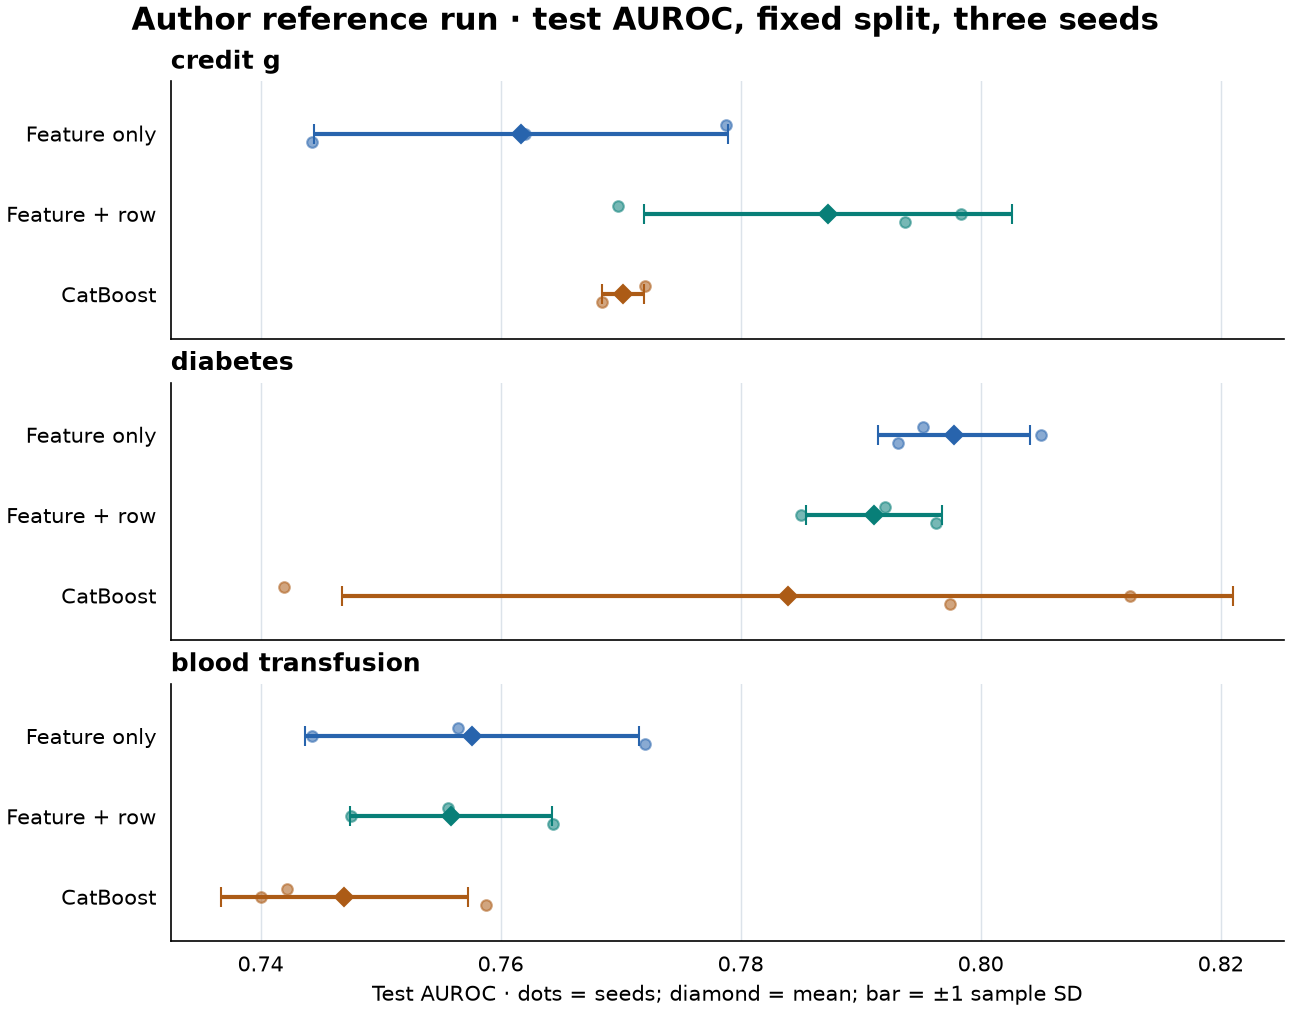

**Measured reference · fixed split, seeds 0/1/2.** Credit_g: feature only 0.7617 ± 0.0173, feature + row 0.7873 ± 0.0153; diabetes: 0.7978 ± 0.0063 vs 0.7911 ± 0.0057; blood transfusion: 0.7576 ± 0.0139 vs 0.7558 ± 0.0084. These are means ± sample SD, not paper results.

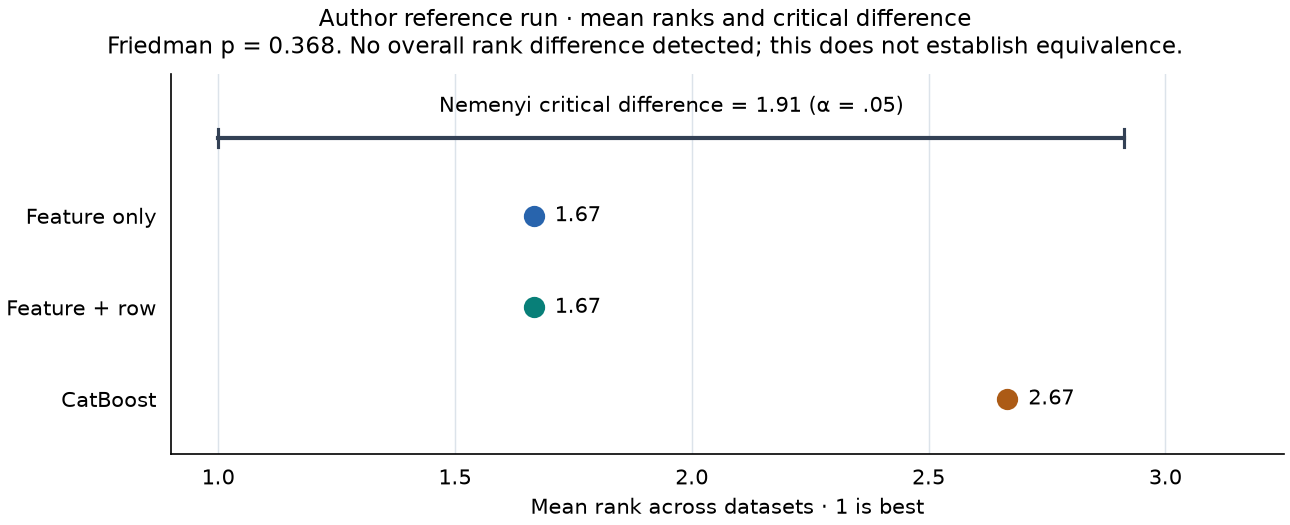

**Measured reference · three datasets.** Friedman p = 0.368; CD = 1.914. The largest mean-rank gap is 1.00, below the CD. This sample does not distinguish the models statistically and does not establish equivalence.

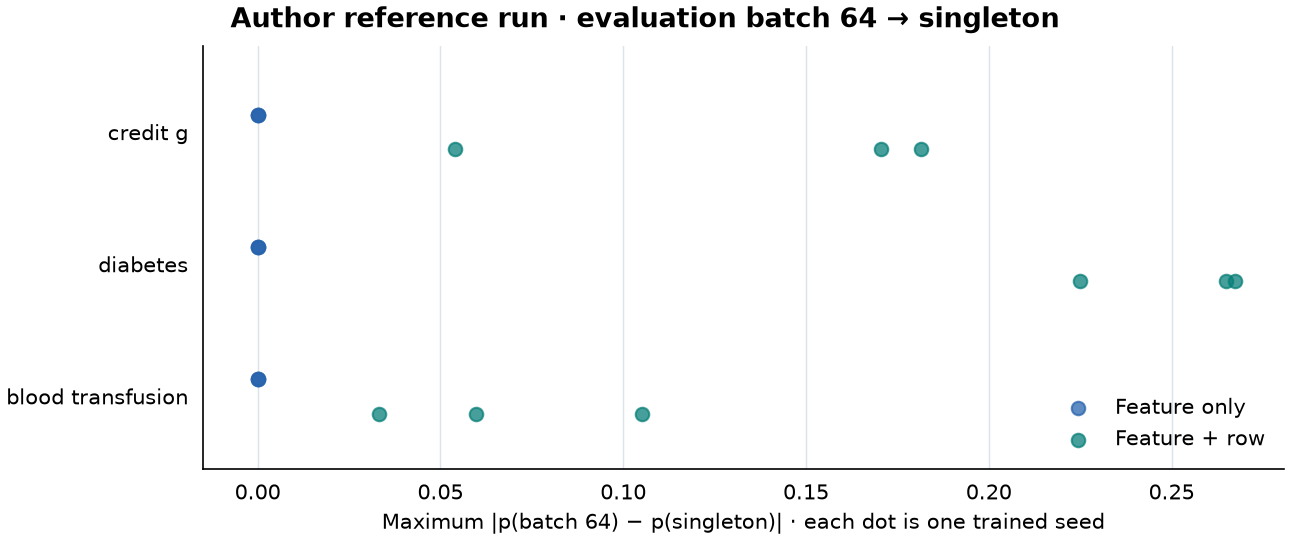

**Measured reference · same trained weights.** Diabetes seed 0 has maximum probability change 0.2673 and AUROC 0.7920 → 0.7648. Feature-only predictions stay unchanged within numerical tolerance. This does not authorize selecting a test-time batch size from test scores.

## EXIT TICKET · your evidence and your explanation

Run the cell, then answer these prompts in your own words. Automated checks establish implementation behavior; they cannot grade your understanding.

1. **Axes:** explain what one element of `[1,B,T*d]` contains and why a column-wise transpose is a different model.
2. **Intervention:** explain the changed-companion and same-batch-permutation results. State the context policy you would put in a model card.
3. **Comparison:** report one dataset's mean ± SD and the paired-seed gaps. Interpret the ranks, Friedman p, and CD without assuming a winner or equivalence.
4. **Paper audit:** name one PDF/release discrepancy, what you implemented, and one reason the local result cannot verify the paper's Table 2.
5. **Pretraining:** identify the correct positive in Task 4 and what a full Table 3 reproduction still needs.

**Your explanation:** _write here; paste it with EXIT output to your teacher. Ask about any step that remains unclear._

In [ ]:
# EXIT — verifiable evidence with no enforced winning model
assert all(checks.values()), 'Fix a failed CHECK before submitting.'
print(f'Implementation/protocol checks: {sum(checks.values())}/{len(checks)} passed')
display(score_table(result).round(4))
print('Mean ranks:', result['results']['mean_ranks'])
print('Friedman:', result['results']['friedman'], '| Nemenyi CD:', result['results']['nemenyi_cd'])
print('Diabetes seed 0 context shift:', probe['max_abs_probability_change'])
print('Executed source SHA256:', source_hash)
print('Artifacts:', artifact_dir.resolve())
print('Scope: local supervised ablation; isolated contrastive loss; full pretraining NOT_RUN.')
print('Full paper-scale Bank: NOT_RUN by this core lab; continue below.')

## 6 · REQUIRED NEXT STEP — attempt the paper's supervised Bank result

The target is **Table 2, Bank, supervised SAINT AUROC 0.9330**, a five-trial mean. It is not the 14-binary-task mean 0.9313. Table 6 reports **SE 0.0009**, not SD. An absolute tolerance of ±0.01 is a declared reproduction target only after the protocols agree. A numerically close result with unresolved protocol gaps remains **INCOMPARABLE**.

| Preset | Data / epochs / seeds | Width / heads / batch | Purpose |
|---|---|---|---|
| `smoke` | 600 Bank rows / 1 / 1 | 4 / 2 / 32 | Confirm data, training, checkpoint, and artifact plumbing |
| `closer` | Full Bank / 20 / 3 | 16 / 4 / 256 | A larger measured attempt |
| `paper` | Full Bank / 100 / 5 | 32 / 8 / 256 | Adopt paper budgets while retaining declared gaps |

The committed **smoke** run reached AUROC 0.742204 and is explicitly INCOMPARABLE. Full `closer` and `paper` results have not been measured here. Their runtime is unmeasured; start with smoke and budget from that timing. Full augmentation/denoising pretraining is still absent.

The source below is split into the **target/configuration ledger** and the **runner**. Read `GAPS` before running. The runner calls the same SAINT class and training functions visible above, saves best weights and test predictions, and prints three separate buckets: verified local findings, paper claim, and scale-up result.

In [ ]:
# PROVIDED — Bank target, presets, and explicit protocol gaps
"""SAINT supervised Bank/Table 2 attempt. Presets do not certify a protocol match.
Run: python labs/_paper_repro_l047.py --preset smoke --output-dir /tmp/l047_smoke
"""
import argparse
import hashlib
import json
import os
from pathlib import Path
import time
import numpy as np
import torch
from sklearn.metrics import roc_auc_score
from relkit.saint_experiment import prepare, environment
from relkit.paper_repro import LabFinding, PaperTarget, ScaleUpRun, classify_number, format_ledger

TARGET = PaperTarget(paper='SAINT (Somepalli et al., 2021)',arxiv='2106.01342',
    table='Table 2, Bank, supervised SAINT',dataset='Bank (OpenML 1461)',metric='AUROC',
    paper_value=.9330,abs_tol=.01,
    notes='Five-trial mean; not the 14-dataset mean 0.9313. Table 6 reports SE 0.0009, not SD.')
PRESETS = {
    'smoke':dict(cap=600,epochs=1,d=4,heads=2,seeds=[0],batch_size=32,ff_dropout=.1,lr=.001),
    'closer':dict(cap=None,epochs=20,d=16,heads=4,seeds=[0,1,2],batch_size=256,ff_dropout=.8,lr=.0001),
    'paper':dict(cap=None,epochs=100,d=32,heads=8,seeds=[0,1,2,3,4],batch_size=256,ff_dropout=.8,lr=.0001),
}
GAPS = [
    'Original five split-index files unavailable: released 65/15/20 assignment, split seed 5.',
    'Paper says 65/15/25 (105%); released data_openml.py uses 65/15/20.',
    'Released normalization LN(x)+F(LN(x)), GEGLU, numeric 1→100→d; prose describes different placement/embedding.',
    'Training-only category vocabulary with reserved unknown; released encoder fits vocabulary to full table.',
    'Paper uses 8 heads; current train.py clamps combined variant to 4. paper preset chooses paper count.',
    'Attention dropout declared but unused in released forward; feed-forward dropout is applied.',
    'Bank only; no reproduction of 14-task mean, semi-supervised Table 3, or superiority over tuned trees.',
]

### Read the runner as an experiment audit

The Bank track uses the released split assignment (65/15/20, split seed 5). Unlike the local learning comparison, its checkpoint choice follows the released binary trainer: **validation accuracy**, checked at zero-based epochs 0, 5, 10, … (reported epochs 1, 6, 11, …). Test AUROC remains the final metric. Do not silently transfer the local validation-AUC protocol to this attempt.

Completed seeds resume only when their recorded identity matches configuration, source files, data/splits, and environment; interrupted seeds restart. Saved best weights support inference, not a full optimizer-state resume. The notebook gate also saves executed cell source and separates output directories by its digest, so editing student code cannot reuse a previous notebook run's completed seeds.

Inspect `protocol.json`, the per-seed histories, prediction row IDs, and the result ledger before comparing the final number with 0.9330.

In [ ]:
# PROVIDED — full Bank runner; uses the model and loops you built above
def main(argv=None):
    parser=argparse.ArgumentParser()
    parser.add_argument('--preset',choices=PRESETS,default='closer')
    parser.add_argument('--output-dir',default=os.environ.get('L047_OUTPUT','l047_artifacts'))
    args=parser.parse_args(argv); cfg=PRESETS[args.preset]
    dest=Path(args.output_dir); dest.mkdir(parents=True,exist_ok=True)
    torch.set_num_threads(1)
    os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG',':4096:8')
    torch.use_deterministic_algorithms(True)
    dev='cuda' if torch.cuda.is_available() else 'cpu'
    fr=prepare('bank_marketing',cap=cfg['cap'],split='released')
    (dest/'protocol.json').write_text(json.dumps(fr['meta'],indent=2))
    from relkit import saint_experiment
    source_dir = Path(saint_experiment.__file__).resolve().parents[1]
    source_hashes = {name: hashlib.sha256((source_dir/name).read_bytes()).hexdigest()
                     for name in ('relkit/saint.py','relkit/saint_experiment.py','_paper_repro_l047.py')}
    values=[]; start=time.time()
    for seed in cfg['seeds']:
        artifact=dest/f'{args.preset}_seed{seed}.json'
        identity=hashlib.sha256(json.dumps({'cfg':cfg,'data':fr['meta']['data_sha256'],
            'split':fr['meta']['split_hashes'],'seed':seed,'source_hashes':source_hashes,'environment':environment()},sort_keys=True).encode()).hexdigest()
        if artifact.exists():
            record=json.loads(artifact.read_text())
            if record.get('identity') != identity:
                raise RuntimeError(f'{artifact} belongs to a different run; use a fresh output directory')
        else:
            torch.manual_seed(seed)
            model=SAINT(fr['xn'].shape[1],fr['cards'],d=cfg['d'],heads=cfg['heads'],
                        ff_dropout=cfg['ff_dropout'],variant='colrow')
            model,hist=train_saint(model,fr['xn'],fr['xc'],fr['y'],fr['train'],fr['valid'],seed=seed,
                epochs=cfg['epochs'],batch_size=cfg['batch_size'],lr=cfg['lr'],device=dev,
                checkpoint=str(dest/f'{args.preset}_seed{seed}_best.pt'),
                select_metric='accuracy',validate_every=5)
            te=fr['test']; pred=predict_saint(model,fr['xn'][te],fr['xc'][te],cfg['batch_size'],dev)
            np.savez(dest/f'{args.preset}_seed{seed}_predictions.npz',row_ids=te,y=fr['y'][te],p=pred)
            record={'identity':identity,'seed':seed,'auc':float(roc_auc_score(fr['y'][te],pred)),
                    'history':hist,'environment':environment()}
            artifact.write_text(json.dumps(record,indent=2))
        values.append(record['auc']); print(f'Bank seed {seed}: AUROC {values[-1]:.6f}',flush=True)
    gaps=GAPS+[f'Preset {args.preset}: {cfg}. Selection follows released binary code: validation accuracy every fifth epoch.']
    run=ScaleUpRun(method='from-scratch SAINT',dataset=TARGET.dataset,metric='AUROC',
        value=float(np.mean(values)),std=float(np.std(values,ddof=1)) if len(values)>1 else None,
        n_seeds=len(values),hardware=str(torch.cuda.get_device_name(0)) if dev=='cuda' else 'CPU',
        wall_s=time.time()-start,protocol_match=False,protocol_deviations=gaps)
    ledger=format_ledger(title='L047 supervised SAINT / Bank',
        lab=[LabFinding('Row-context mechanism and local ablation','See _check_l047_results.json and _verify_l047_results.json',
                        'Three substitute datasets; no pretraining')],
        paper=[(TARGET,run,classify_number(TARGET,run))],
        extra_lines=[f'Descriptive delta from Bank 0.9330: {run.value-.9330:+.6f}; ±0.01 tolerance applies only after protocol agreement.',
                     'Completed seeds resume; interrupted seeds restart. Best weights support inference, not optimizer resume.'])
    out={'preset':args.preset,'source_hashes':source_hashes,'config':cfg,'environment':environment(),'scores':values,'ledger':ledger}
    (dest/f'{args.preset}_results.json').write_text(json.dumps(out,indent=2))
    print(ledger); return out

### Deliberate compute · persist the artifacts

Set `RUN_PAPER_REPRO=True` after choosing a budget. Start with `PRESET='smoke'`, then run `closer`. For Colab, attach a GPU and mount Drive before setting `OUTPUT_DIR` to a persistent directory. Free Colab may disconnect during unattended work; use the supplied Modal runner for longer runs:

```bash
modal run --detach modal/l047_paper_repro.py --preset closer
modal volume get relational-artifacts l047/closer ./l047-bank-results
```

Modal runs the canonical from-scratch implementation from the repo; the gated notebook trains your checked inlined implementation. Both use the same architecture/protocol code. The site/notebook must be published before a fresh Colab clone can obtain local changes.

**After the run:** compare the measured mean and uncertainty with the target, enumerate unresolved `GAPS`, and report MATCH/CLOSE/FAIL only if protocol agreement permits it. Otherwise report INCOMPARABLE with the measured number. Until a run executes, its status is NOT_RUN.

In [ ]:
# PROVIDED — explicit gate; saved source distinguishes notebook implementations
RUN_PAPER_REPRO = False
PRESET = 'closer'  # first deliberate run: change to 'smoke'
OUTPUT_DIR = 'l047_artifacts'  # Colab: use a mounted persistent Drive directory
if RUN_PAPER_REPRO:
    # Re-running identical cells must not create a new run identity or retrain completed seeds.
    notebook_source = '\n\n# --- next executed cell ---\n\n'.join(dict.fromkeys(get_ipython().history_manager.input_hist_raw[1:]))
    notebook_hash = hashlib.sha256(notebook_source.encode()).hexdigest()
    run_dir = Path(OUTPUT_DIR) / f'notebook-{notebook_hash[:16]}'
    run_dir.mkdir(parents=True, exist_ok=True)
    (run_dir / 'executed_cells.py').write_text(notebook_source)
    paper_result = main(['--preset', PRESET, '--output-dir', str(run_dir)])
else:
    print('NOT_RUN: paper-scale Bank. Start with smoke, then run closer with persistent storage.')

### Revisit after a delay

Tomorrow, without reading this notebook, sketch the two attention axes and state whether shuffling a fixed batch and replacing a batch member are the same intervention. Then name the minimum artifacts needed to regenerate one Bank number. Reopen only the section needed to correct your answer.

**Figure provenance:** `_figures_l047.py` regenerates mechanism diagrams from the lesson's SVG components and author-reference plots from measured JSON; `figures/l047/provenance.json` records hashes. The PNGs are embedded directly in the markdown as data URLs, the format used by Colab, so viewing them does not depend on running JavaScript or finding an adjacent image folder.